In [1]:
import pandas as pd
import polars as pl

In [2]:
cluster_data = pd.read_csv('turmas_com_clusters.csv')
cluster_data.sort_values(by=["id_turma", "media_final_geral"], inplace=True)
cluster_data.reset_index(drop=True, inplace=True)
#cluster_data.to_csv('cluster_data.csv', index=False)
cluster_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id_turma                    125793 non-null  int64  
 1   qtd_discentes               125793 non-null  int64  
 2   proporcao_aprovados         125793 non-null  float64
 3   media_final_geral           125793 non-null  float64
 4   postura_profissional_media  125793 non-null  float64
 5   postura_profissional_DP     125793 non-null  float64
 6   atuacao_profissional_media  125793 non-null  float64
 7   atuacao_profissional_DP     125793 non-null  float64
 8   cluster                     125793 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 8.6 MB


In [3]:
turmas_data = pd.read_csv("../dataset/avaliacoes_Docentes_Turmas.csv", sep=';')
turmas_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126294 entries, 0 to 126293
Data columns (total 28 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  

In [4]:
turmas_data["proporcao_aprovados"] = (
    turmas_data["qtd_aprovado"] + turmas_data["qtd_aprovado_por_nota"]
) / turmas_data["qtd_discentes"]
turmas_data["proporcao_reprovados"] = 1 - turmas_data["proporcao_aprovados"]

turmas_data["formacao"] = turmas_data["formacao"].replace(
    {"ESPECIALIZAÇÃO": "ESPECIALISTA", "MESTRADO": "MESTRE", "DOUTORADO": "DOUTOR", "GRADUAÇÃO":"OUTROS", "PÓS-DOUTORADO":"DOUTOR", "DESCONHECIDA":"OUTROS"}
)

turmas_data.dropna(subset=['id_turma', 'proporcao_aprovados'], inplace=True)
turmas_data.sort_values(by=["id_turma", "media_final_geral"], inplace=True)
turmas_data.reset_index(drop=True, inplace=True)
turmas_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  125793 non-null  object 
 1   sexo                                  125793 non-null  object 
 2   formacao                              125793 non-null  object 
 3   vinculo                               125793 non-null  object 
 4   categoria                             125793 non-null  object 
 5   classe_funcional                      125793 non-null  object 
 6   lotacao                               125793 non-null  object 
 7   id_turma                              125793 non-null  int64  
 8   ano                                   125793 non-null  int64  
 9   periodo                               125793 non-null  int64  
 10  qtd_discentes                         125793 non-null  int64  
 11  

In [5]:
merged_data = pd.concat([turmas_data, cluster_data[['id_turma', 'cluster']]], axis=1, join='inner')
merged_data.info()
merged_data.to_csv('turmas_com_clusters_e_avaliacoes.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  125793 non-null  object 
 1   sexo                                  125793 non-null  object 
 2   formacao                              125793 non-null  object 
 3   vinculo                               125793 non-null  object 
 4   categoria                             125793 non-null  object 
 5   classe_funcional                      125793 non-null  object 
 6   lotacao                               125793 non-null  object 
 7   id_turma                              125793 non-null  int64  
 8   ano                                   125793 non-null  int64  
 9   periodo                               125793 non-null  int64  
 10  qtd_discentes                         125793 non-null  int64  
 11  

# Análise dos clusters

In [6]:
merged_data = pd.read_csv('turmas_com_clusters_e_avaliacoes.csv')

cluster              0         1         2         3
formacao                                            
DOUTOR        0.722089  0.878441  0.849757  0.945145
ESPECIALISTA  0.075129  0.029360  0.034098  0.007645
MESTRE        0.201999  0.090750  0.115889  0.046912
OUTROS        0.000783  0.001449  0.000257  0.000297


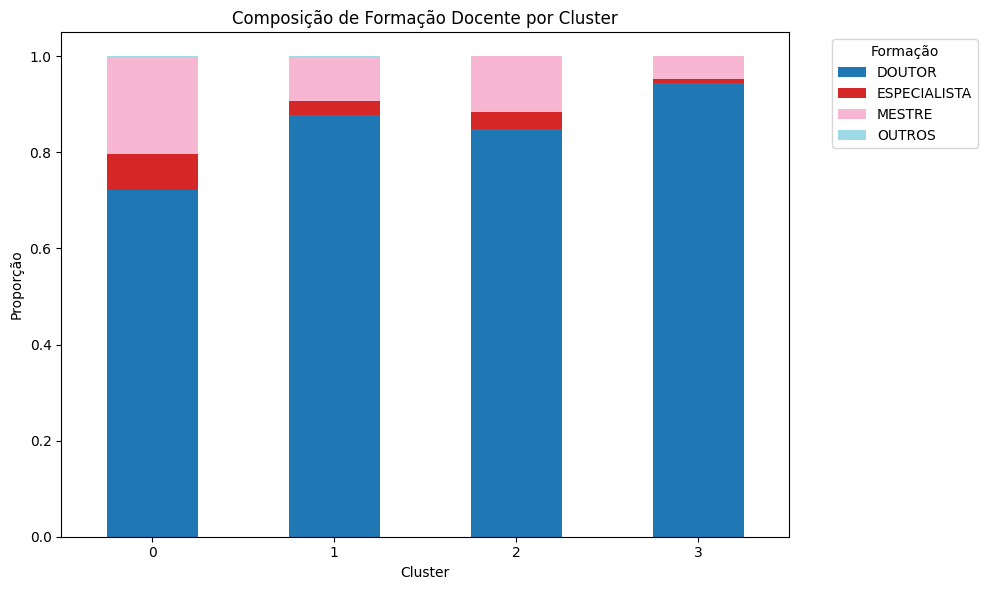

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# distribuição de formacao por cluster
formacao_cluster = (
    df.groupby(['cluster', 'formacao'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
formacao_cluster['proporcao'] = (
    formacao_cluster.groupby('cluster')['count']
    .transform(lambda x: x / x.sum())
)

print(formacao_cluster.pivot(index='formacao', columns='cluster', values='proporcao'))

# Stacked bar chart
pivot_formacao = formacao_cluster.pivot(index='cluster', columns='formacao', values='proporcao').fillna(0)

pivot_formacao.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Composição de Formação Docente por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.legend(title='Formação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cluster        0         1         2         3
sexo                                          
F        0.52483  0.371692  0.473164  0.326603
M        0.47517  0.628308  0.526836  0.673397


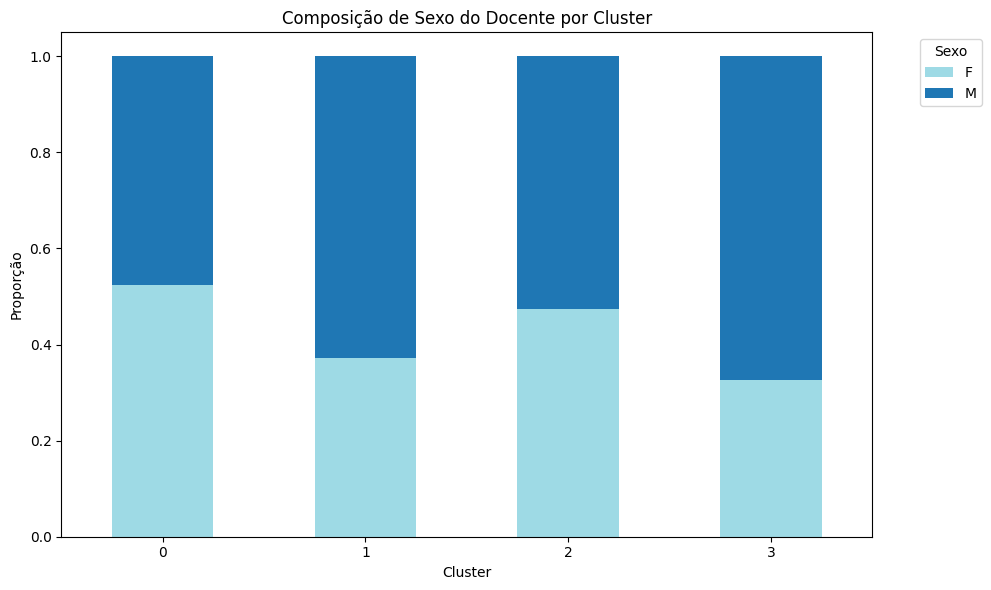

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# distribuição de formacao por cluster
formacao_cluster = (
    df.groupby(['cluster', 'sexo'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
formacao_cluster['proporcao'] = (
    formacao_cluster.groupby('cluster')['count']
    .transform(lambda x: x / x.sum())
)

print(formacao_cluster.pivot(index='sexo', columns='cluster', values='proporcao'))

# Stacked bar chart
pivot_formacao = formacao_cluster.pivot(index='cluster', columns='sexo', values='proporcao').fillna(0)

pivot_formacao.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20_r')
plt.title('Composição de Sexo do Docente por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporção')
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Achei interessante
# Menores avaliações médias gerais tem maior proporção de homens
# Cluster de maior sucesso é o com menor proporção de homens

df = merged_data.copy()

df['sexo'] = df['sexo'].map({'M': 1, 'F': 0})

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'mean',
    'qtd_discentes': 'mean',
    'media_final_geral': 'mean',
    'sexo': 'mean',
    'atuacao_profissional_media': 'mean',
    'postura_profissional_media': 'mean',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Proporção Masculina',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').transpose()

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format("{:.3f}")
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,0.972,0.869,0.943,0.581
Quantidade de Discentes,12.935,26.256,26.984,32.838
Média Final Geral,8.257,7.716,8.078,6.534
Proporção Masculina,0.475,0.628,0.527,0.673
Atuação Profissional,9.741,8.094,9.100,8.706
Postura Profissional,9.845,7.861,9.390,9.309
